# Setup

In [1]:

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

# dataset dirs follow conf/dataset/*/default.yaml: ${root}/${dataset.dir}
DATA = Path('/home/nik/workspace/ImperialWork/msc_project/SyncNetProject/data')
SOC_NPZ = DATA / 'sort_of_clevr-seed1-train36000-test1000-q10-t-1' / 'test.npz'
SQOOP_NPZ = DATA / 'sqoop-seed0-train1080000-test25600-rhs18' / 'val_seen.npz'

OUT_DIR = Path('./outputs') / 'figures'
CHAP_DATASETS = OUT_DIR / 'chap:datasets'
CHAP_RESULTS = OUT_DIR / 'chap:results'
CHAP_DATASETS.mkdir(parents=True, exist_ok=True)
CHAP_RESULTS.mkdir(parents=True, exist_ok=True)


import plotly.graph_objects as go
from plotly.subplots import make_subplots

COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
LAYOUT = dict(template='simple_white', font=dict(family='serif', size=13), margin=dict(l=50, r=20, t=30, b=45), legend=dict(orientation='h', yanchor='bottom', y=1.02, x=0))


def show(fig, name, folder=None, width=640, height=420):
    fig.update_layout(width=width, height=height, **LAYOUT)
    folder = folder or CHAP_RESULTS
    folder.mkdir(parents=True, exist_ok=True)
    fig.write_html(folder / f'{name}.html', include_plotlyjs='cdn')
    try:
        fig.write_image(folder / f'{name}.png', scale=3)
        fig.write_image(folder / f'{name}.pdf')
    except Exception as e:
        print(f'{name}: static export needs kaleido ({e.__class__.__name__}); html written')
    fig.show()


In [ ]:
SOC, SQ = 'sort_of_clevr', 'sqoop'
PAIR_VARIETY = [1, 2, 4, 8, 18, 35]
T_TEST = [1, 2, 4, 6, 8, 12, 16]

MAIN = {
    SOC: {
        'Q-Only': '5c938564b4',
        'CNN+MLP': '7f69d35494',
        'RelNet': '1bba57eaba',
        'FiLM': 'cce2a7dc79',
        'Transformer': 'f480f82d5a',
        'Workspace': 'ef208275ef',
        'SyncNet': ['bd2c173785', '3a2e33b268'],
    },
    SQ: {
        'Q-Only': {1: 'da868e47f3', 2: '8c385b2059', 4: 'b53f5ecb08', 8: 'c7cfb0dd1c', 18: 'd640141c57', 35: 'a09acf017b'},
        'Conv+LSTM': {1: ['4dd2f8a5f6', '030e2fbb5c'], 2: ['b838865278', '2bf9832aac'], 4: ['11380cec6a', '1b4f721c75'], 8: ['125ce8d50e', '6b2957d7de'], 18: ['6828367e4c', '5f2e70cb1e'], 35: ['d6cbb5b004', 'a2ff50a58f']},
        'RelNet': {1: ['d91b42c323', 'b542189d54'], 2: ['41515ce582', 'ab085716db'], 4: ['46ef70288f', '44d2c2dc89'], 8: ['f15b7d0159', '2d24259822'], 18: ['fd877702cb', 'e61bdb6b4b'], 35: '18a92d8762'},
        'FiLM': {1: ['48c351e38b', '73bc0a0e0d'], 2: ['cbbfbd61a7', '52c99bc7b5'], 4: ['13e08caaa4', 'c61805702d'], 8: ['70f71488ff', 'd4892fa784'], 18: ['4cf87adb37', '187a5c81b5'], 35: ['dd57cc6026', '5909eef4cc']},
        'Transformer': {1: '0d1162f980', 2: '30f0e4636f', 4: '309d772f74', 8: '12f14a1e08', 18: ['cb7f991249', '556651c974'], 35: 'cb057ccfe6'},
        'Workspace': {1: '53921fc0cc', 2: '982e336df1', 4: '5e11bd62b0', 8: '402a405105', 18: ['4482197917', '6cc38fc0d1'], 35: 'cc51c8cefc'},
        'SyncNet': {1: ['7c2f6df64c', '0feed42fb0'], 2: 'c4fc634d30', 4: '45f164b718', 8: 'baca354a63', 18: ['9f272ac176', 'f9b162b2bf'], 35: 'f61d1910b7'},
    },
}

ABLATION_ROWS = ['canonical', 'no_bias', 'hard_partition', 'anchors_off', 'cells_off', 'silent', 'static_addr', 'lines_attn', 'with_prior_term', 'seed_random', 'cnn_stem']
ABLATIONS = {
    SOC: {
        'canonical': 'bd2c173785',
        'no_bias': 'd7072ec57d',
        'hard_partition': '3986545b38',
        'anchors_off': '96cb2d6dc8',
        'cells_off': '8fbb02c9c0',
        'silent': '77baf6a31a',
        'static_addr': 'b09a365569',
        'lines_attn': 'bbb6a6f7eb',
        'with_prior_term': '28033fa5ab',
        'seed_random': 'b7a247256a',
        'cnn_stem': '5f683fd1b5',
    },
    SQ: {
        1: {
            'canonical': ['7c2f6df64c', '0feed42fb0'],
            'no_bias': ['6917200a5f', '8dd2b497ad'],
            'hard_partition': ['c30768ddf4', '0b42bc64f1'],
            'anchors_off': '9a75f2f565',
            'cells_off': 'fdcc50696f',
            'silent': ['c9c95bda21', '8463597a1a'],
            'static_addr': ['1beba23c65', '40408a636c'],
            'lines_attn': ['e582e0c1eb', '705e3a9f75'],
            'with_prior_term': 'fba3052828',
            'seed_random': '203081e4fb',
            'cnn_stem': None,
        },
        18: {
            'canonical': ['9f272ac176', 'f9b162b2bf'],
            'no_bias': '20182acf1b',
            'hard_partition': 'fc23127fcc',
            'anchors_off': None,
            'cells_off': None,
            'silent': 'a1142183d7',
            'static_addr': '9daf23bd7b',
            'lines_attn': '0e17b36177',
            'with_prior_term': ['9f0c939a32', '7656abe54a'],
            'seed_random': 'b14851cdf7',
            'cnn_stem': None,
        },
    },
}

SWEEPS = {
    SOC: {
        't_train': {2: '2b9e6b890b', 4: '0ddfd86b22', 8: 'bd2c173785', 16: '50c47b416e'},
        'phase_dim': {2: 'ca9c20344c', 3: '4c476b02eb', 4: 'a9b3ddbed9', 6: 'bd2c173785', 8: 'f545ccea93'},
        'n_modules': {4: '0b69be29f7', 6: 'bd2c173785', 8: 'cc1f364afe', 12: '7352fba590'},
    },
    SQ: {
        1: {
            't_train': {2: '3b20236873', 4: '3e93342d3e', 8: ['7c2f6df64c', '0feed42fb0'], 16: 'e895e9bf94'},
            'phase_dim': {2: '28ac8ae81a', 3: '3d2b97e3f6', 4: '406f1a7916', 6: ['7c2f6df64c', '0feed42fb0'], 8: '52f6e34314'},
            'n_modules': {4: 'e530e6ab5a', 6: ['7c2f6df64c', '0feed42fb0'], 8: '3c2d49842f', 12: '22165def5f'},
        },
    },
}

SEEDING = {
    SOC: {'learned': ['bd2c173785', '3a2e33b268'], 'partition': ['6a6ee1ecbb', '7c5afa9916'], 'random': 'b7a247256a'},
    SQ: {
        18: {
            'partition 1': 'b912886f99',
            'partition 2': '30100689be',
            'partition 4': ['9f272ac176', 'f9b162b2bf'],
            'partition 8': '5d7d8e020a',
            'partition 50': 'fc23127fcc',
            'random': 'b14851cdf7',
            'zero': '5f58c04ab4',
        },
    },
}

BASELINE_VARIANTS = {
    SOC: {
        'Transformer': {'patchify': 'd50b23e608', 'stem': '3882f22ae4', 'stem + lr 1e-4': '9191febd8e', 'stem + 4 layers': 'f480f82d5a', 'stem + 4 layers + lr 1e-4': 'ba54805b12'},
        'Workspace': {'patchify': 'e2b5f79b1c', 'stem': 'ef208275ef', 'stem + lr 1e-4': '682219df8a', 'stem, unlooped': 'e303138fbb'},
        'RelNet': {'5x5': '1bba57eaba', '8x8': '8b5d57d742'},
    },
    SQ: {
        18: {
            'Transformer': {'patchify': '17110fa882', 'stem': ['5977899d9c', 'e0072dd6fb'], 'stem + lr 1e-4': ['cb7f991249', '556651c974'], 'stem + batch 2048': ['458f372de2', '8b1ac67a5f'], 'stem + batch 2048, equal samples': 'a3f9b41e96', 'stem, 6 layers': '200dc5c895', 'question as token': 'bc3f947202', 'question as FiLM': '8c7416a98f', 'stem + warmup 10k': 'd7dbeefd33', 'stem, 6 layers + batch 2048': '849e7b0a2c'},
            'Workspace': {'patchify': 'f3743655aa', 'stem': ['3ccbe5ed6c', 'd7f7b2b016'], 'stem + lr 1e-4': ['4482197917', '6cc38fc0d1'], 'stem + batch 2048': ['77135ca9fe', 'dd2e691e0e'], 'stem, top-k 1.0': 'a372b37a0f', 'stem, top-k 0.5': '4e131b07af', 'stem, unlooped': '0b1129a83b', 'stem, unlooped + batch 2048': '5c875931a2', 'stem, 6 layers': 'd0d98c7170'},
            'RelNet': {'5x5': ['fd877702cb', '47a327d9a5'], '8x8': ['534b8807f2', '53cc1eeb61'], '8x8 + lr 1e-4': '96b1af6ffb', '8x8 + batch 2048': ['da8c0421ca', '3964543d7f'], '8x8, g 512': 'b3711f1b4d', '8x8, f 512': '9a887c5f8f', '8x8 + warmup 10k': 'db6c43f710'},
            'Conv+LSTM': {'base': ['6828367e4c', '35d27c8269', '78b21a9c96'], 'lr 1e-4': ['164137e47a', '090c591363', '8cd8799e02'], 'batch 2048': ['326b940bbf', '287e27dd68'], 'batch 2048 + lr 1e-4': '6b1dac127a', 'warmup 10k': 'b9e49363cf'},
        },
    },
}

RELNET_TUNED = {SQ: {1: None, 18: ['da8c0421ca', '3964543d7f']}}

LR_CONTROL = {SQ: {1: 'aa34e9c044', 18: '0526ae081d'}}

METRICS = {
    SOC: {'Overall': 'test_callbacks/accuracy', 'Non-relational': 'test_callbacks/non_relational_accuracy', 'Binary': 'test_callbacks/binary_accuracy', 'Ternary': 'test_callbacks/ternary_accuracy'},
    SQ: {'validation': 'eval_callbacks/accuracy', 'held-out': 'test_callbacks/accuracy'},
}
SUBTYPES = {
    'Non-relational': {'Query shape': 'query_shape', 'Left of centre': 'left_of_centre', 'Top half': 'top_half'},
    'Binary': {'Closest shape': 'closest_shape', 'Furthest shape': 'furthest_shape', 'Count same shape': 'count_same_shape'},
    'Ternary': {'Count in box': 'count_in_box', 'On band': 'on_band', 'Count obtuse': 'count_obtuse'},
}
T_VARIANCE = {'Overall': 't_variance/acc_mean_T{}', 'Binary': 't_variance/binary_mean_T{}', 'Ternary': 't_variance/ternary_mean_T{}'}
INTERVENTIONS = {'Freeze': 'phase_freeze', 'Zero': 'phase_zero', 'Shuffle': 'phase_shuffle', 'Anchor shuffle': 'anchor_shuffle'}
ASSEMBLED = ('test_callbacks/ternary_accuracy', 0.70)

TABLES = OUT_DIR / 'tables'
TABLES.mkdir(parents=True, exist_ok=True)


In [3]:
import wandb

RUNS = {}
for task in (SOC, SQ):
    rows = [{'Created': str(r.created_at), **r.config, **{k: v for k, v in r.summary.items() if isinstance(v, (int, float))}}
            for r in wandb.Api(timeout=120).runs(f'niks_priv/{task}', filters={'tags': 'v16', 'state': 'finished'})]
    RUNS[task] = pd.json_normalize(rows).sort_values('Created').drop_duplicates(['cfg_hash', 'train.seed'], keep='last')


def runs(task, cfg_hash):
    df = RUNS[task]
    hashes = cfg_hash if isinstance(cfg_hash, list) else [cfg_hash]
    return df[df.cfg_hash.isin([h for h in hashes if h])]


def stat(task, cfg_hash, col):
    r = runs(task, cfg_hash)
    v = 100 * r[col].dropna() if col in r else pd.Series(dtype=float)
    return (v.mean(), v.std(ddof=1) if len(v) > 1 else 0.0, len(v)) if len(v) else (np.nan, np.nan, 0)


def fmt(task, cfg_hash, col):
    m, s, n = stat(task, cfg_hash, col)
    return '—' if np.isnan(m) else f'{m:.1f} ± {s:.1f} ({n})'


def table(rows, cols, task):
    return pd.DataFrame({c: {label: fmt(task, h, col) for label, h in rows.items()} for c, col in cols.items()})


def save(df, name):
    df.to_csv(TABLES / f'{name}.csv')
    df.to_latex(TABLES / f'{name}.tex', escape=False)
    return df


main = runs(SOC, MAIN[SOC]['SyncNet']).iloc[0] if len(runs(SOC, MAIN[SOC]['SyncNet'])) else pd.Series(dtype=object)


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


# Chapter 3

In [6]:
import matplotlib.pyplot as plt

In [4]:
# Table 3.1
CANONICAL = {'Modules M': 'model.n_modules', 'Phase dimension d': 'model.phase_dim', 'Internal steps T': 'model.t_bus', 'Step size γ': 'model.dt', 'Module state d_h': 'model.module_dim', 'Message d_m': 'model.msg_dim', 'Oscillators per cell': 'model.field_osc_dim', 'Field steps T_x': 'model.field_T', 'Field step size γ_x': 'model.field_dt', 'Competition temperature β': 'model.slot_beta', 'Spatial bias b_k(p)': 'model.claim_prior', 'Bias initialisation': 'model.claim_prior_init'}
save(pd.Series({k: main.get(c, '—') for k, c in CANONICAL.items()}, name='value').to_frame(), 'canonical')


,value
Modules M,6.0
Phase dimension d,6.0
Internal steps T,8.0
Step size γ,0.5
Module state d_h,96.0
Message d_m,4.0
Oscillators per cell,—
Field steps T_x,—
Field step size γ_x,—
Competition temperature β,—


# Chapter 4

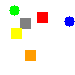

In [7]:
soc = np.load(SOC_NPZ, allow_pickle=False)

scene = 0
plt.imsave(CHAP_DATASETS / 'soc_example.png', soc['images'][scene][..., ::-1])   # stored BGR (cv2)
display(Image(CHAP_DATASETS / 'soc_example.png'))

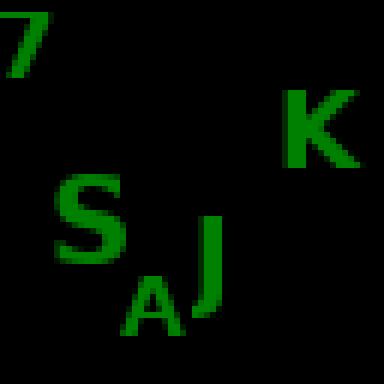

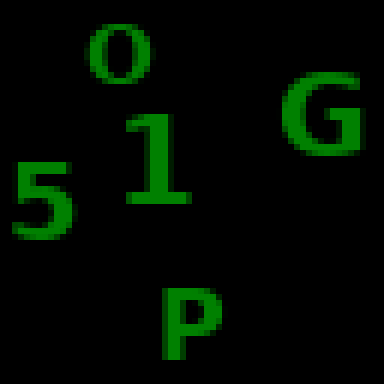

In [8]:
sq = np.load(SQOOP_NPZ, allow_pickle=True)

for i in range(2):
    plt.imsave(CHAP_DATASETS / f'sqoop_example_{i}.png', np.kron(sq['images'][i], np.ones((6, 6, 1), dtype=np.uint8)))
    display(Image(CHAP_DATASETS / f'sqoop_example_{i}.png'))

# Chapter 5.1 — Sort-of-CLEVR

In [9]:
# Table 5.1
soc_results = table(MAIN[SOC], METRICS[SOC], SOC)
soc_results.insert(0, 'Params', [f"{runs(SOC, h).n_params.iloc[0] / 1e6:.2f}M" if len(runs(SOC, h)) else '—' for h in MAIN[SOC].values()])
save(soc_results, 'soc_results')


,Params,Overall,Non-relational,Binary,Ternary
Q-Only,0.02M,49.4 ± 0.2 (5),50.7 ± 0.3 (5),43.6 ± 0.5 (5),54.1 ± 0.2 (5)
CNN+MLP,1.39M,64.7 ± 0.1 (5),63.3 ± 0.3 (5),74.5 ± 0.2 (5),56.2 ± 0.2 (5)
RelNet,0.85M,87.4 ± 1.2 (5),99.9 ± 0.0 (5),95.6 ± 0.5 (5),66.6 ± 3.1 (5)
FiLM,2.78M,93.6 ± 0.4 (5),99.9 ± 0.1 (5),97.4 ± 0.2 (5),83.5 ± 0.9 (5)
Transformer,0.63M,96.7 ± 0.9 (2),100.0 ± 0.0 (2),98.7 ± 0.5 (2),91.4 ± 3.1 (2)
Workspace,0.58M,94.2 ± 4.0 (3),100.0 ± 0.0 (3),98.4 ± 1.1 (3),84.3 ± 11.0 (3)
SyncNet,0.67M,91.4 ± 1.7 (9),99.9 ± 0.1 (9),98.6 ± 0.3 (9),75.8 ± 5.1 (9)


In [10]:
# Table 5.2 (main rows) and the appendix rows
MAIN_ROWS = ['canonical', 'no_bias', 'hard_partition', 'anchors_off', 'cells_off', 'silent', 'static_addr', 'lines_attn', 'seed_random']
col, thr = ASSEMBLED
ablations = pd.DataFrame(index=ABLATION_ROWS)
ablations['SoC accuracy'] = [fmt(SOC, ABLATIONS[SOC][r], METRICS[SOC]['Overall']) for r in ABLATION_ROWS]
ablations['SoC ternary'] = [fmt(SOC, ABLATIONS[SOC][r], METRICS[SOC]['Ternary']) for r in ABLATION_ROWS]
ablations['SoC assembled'] = [f"{(runs(SOC, ABLATIONS[SOC][r])[col] > thr).sum()}/{len(runs(SOC, ABLATIONS[SOC][r]))}" if len(runs(SOC, ABLATIONS[SOC][r])) else '—' for r in ABLATION_ROWS]
for v in (1, 18):
    ablations[f'SQOOP held-out ({v})'] = [fmt(SQ, ABLATIONS[SQ][v][r], METRICS[SQ]['held-out']) for r in ABLATION_ROWS]
save(ablations.loc[MAIN_ROWS], 'ablations')
save(ablations.drop(MAIN_ROWS), 'ablations_extra')


,SoC accuracy,SoC ternary,SoC assembled,SQOOP held-out (1),SQOOP held-out (18)
with_prior_term,91.8 ± 2.8 (6),77.4 ± 7.5 (6),5/6,72.4 ± 7.4 (5),99.9 ± 0.1 (4)
cnn_stem,90.5 ± 1.3 (5),75.1 ± 3.4 (5),5/5,—,—


In [11]:
# Table 5.3
drops = {k: f'test_interventions/{v}_drop' for k, v in INTERVENTIONS.items()}
interventions = pd.concat([table({'Sort-of-CLEVR': MAIN[SOC]['SyncNet']}, drops, SOC), table({'SQOOP (18)': MAIN[SQ]['SyncNet'][18], 'SQOOP (1)': MAIN[SQ]['SyncNet'][1]}, drops, SQ)])
save(interventions, 'interventions')


,Freeze,Zero,Shuffle,Anchor shuffle
Sort-of-CLEVR,62.8 ± 12.2 (9),56.3 ± 14.5 (9),11.9 ± 9.4 (9),32.5 ± 6.8 (9)
SQOOP (18),—,—,—,—
SQOOP (1),—,—,—,—


# Chapter 5.2 — SQOOP

In [12]:
# Figure 5.2 -- SQOOP: validation (top) and held-out (bottom) by pair variety
models = [m for m in MAIN[SQ] if any(stat(SQ, h, METRICS[SQ]['held-out'])[2] for h in MAIN[SQ][m].values())]
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.06, subplot_titles=('validation (seen pairs)', 'held-out (unseen pairs)'))
for r, (split, col) in enumerate(METRICS[SQ].items(), start=1):
    for i, m in enumerate(models):
        mean, sd, n = zip(*[stat(SQ, MAIN[SQ][m][v], col) for v in PAIR_VARIETY])
        fig.add_trace(go.Bar(x=[str(v) for v in PAIR_VARIETY], y=mean, name=m, marker_color=COLORS[i % len(COLORS)], legendgroup=m, showlegend=(r == 1),
                             error_y=dict(type='data', array=sd, visible=True, thickness=1), customdata=np.c_[sd, n],
                             hovertemplate=f'{m}<br>pair variety %{{x}}<br>%{{y:.1f}} ± %{{customdata[0]:.1f}} (n=%{{customdata[1]}})<extra></extra>'), row=r, col=1)
    fig.add_hline(y=50, line=dict(color='grey', dash='dot', width=1), row=r, col=1)
    fig.update_yaxes(title='Accuracy (%)', range=[40, 101], row=r, col=1)
fig.update_xaxes(title='Pair variety', row=2, col=1)
fig.update_layout(barmode='group', bargap=0.15)
show(fig, 'sqoop_results_bars_stacked', width=760, height=560)


sqoop_results_bars_stacked: static export needs kaleido (ValueError); html written


In [13]:
# Figure 5.4 -- sweeps: Sort-of-CLEVR families and the SQOOP rhs=1 held-out line on the same panels
def sweep(axis, xlabel, name, cols=lambda x: METRICS[SOC]):
    fig = go.Figure()
    series = [(fam, SOC, SWEEPS[SOC][axis], cols, dict(color=COLORS[i])) for i, fam in enumerate(METRICS[SOC])]
    series += [('SQOOP (1)', SQ, SWEEPS[SQ][1].get(axis, {}), lambda x: {'SQOOP (1)': METRICS[SQ]['held-out']}, dict(color='black', dash='dash'))]
    for label, task, cells, cols_, line in series:
        pts = [(x, *stat(task, h, cols_(x).get(label))[:2]) for x, h in cells.items()]
        pts = [p for p in pts if not np.isnan(p[1])]
        if not pts: continue
        x, m, s = map(np.array, zip(*pts))
        rgba = line['color'] if line['color'] != 'black' else '#000000'
        fig.add_trace(go.Scatter(x=np.r_[x, x[::-1]], y=np.r_[m + s, (m - s)[::-1]], fill='toself', fillcolor=rgba, opacity=0.12, line=dict(width=0), showlegend=False, hoverinfo='skip'))
        fig.add_trace(go.Scatter(x=x, y=m, mode='lines+markers', name=label, line=line, marker=dict(size=6, symbol='square' if task == SQ else 'circle'),
                                 customdata=s, hovertemplate=f'{label}<br>{xlabel}=%{{x}}<br>%{{y:.1f}} ± %{{customdata:.1f}}<extra></extra>'))
    canon = main.get({'t_train': 'model.t_bus', 'phase_dim': 'model.phase_dim', 'n_modules': 'model.n_modules'}.get(axis, 'model.t_bus'))
    if pd.notna(canon): fig.add_vline(x=canon, line=dict(color='grey', dash='dot', width=1))
    fig.update_xaxes(title=xlabel, tickvals=list(cells) if axis != 't_test' else T_TEST)
    fig.update_yaxes(title='Accuracy (%)')
    show(fig, name, width=520, height=380)


SWEEPS[SOC]['t_test'] = {T: MAIN[SOC]['SyncNet'] for T in T_TEST}
sweep('t_test', 'Test-time steps T', 'soc_ablation_t_test', cols=lambda T: {fam: col.format(T) for fam, col in T_VARIANCE.items()})
sweep('t_train', 'Internal steps T', 'soc_ablation_t_train')
sweep('n_modules', 'Number of modules M', 'soc_ablation_n_modules')
sweep('phase_dim', 'Phase dimension d', 'soc_ablation_phase_dim')


soc_ablation_t_test: static export needs kaleido (ValueError); html written


soc_ablation_t_train: static export needs kaleido (ValueError); html written


soc_ablation_n_modules: static export needs kaleido (ValueError); html written


soc_ablation_phase_dim: static export needs kaleido (ValueError); html written


# Appendix

In [14]:
# Appendix: assembly rate -- bars = fraction of runs assembled, points = every run's accuracy
variants = {'canonical': ABLATIONS[SOC]['canonical'], 'no bias': ABLATIONS[SOC]['no_bias'], 'anchors shared': ABLATIONS[SOC]['anchors_off'], 'cells shared': ABLATIONS[SOC]['cells_off'], 'hard partition': ABLATIONS[SOC]['hard_partition'], 'partition seed': SEEDING[SOC]['partition'], 'random seed': SEEDING[SOC]['random']}
col, thr = ASSEMBLED
fig = go.Figure()
for i, (label, h) in enumerate(variants.items()):
    r = runs(SOC, h)
    if r.empty: continue
    fig.add_trace(go.Bar(x=[label], y=[100 * (r[col] > thr).mean()], marker_color='lightgrey', name='assembled (%)', showlegend=(i == 0), hovertemplate=f'{label}<br>assembled %{{y:.0f}}%<extra></extra>'))
    fig.add_trace(go.Scatter(x=[label] * len(r), y=100 * r[METRICS[SOC]['Overall']], mode='markers', marker=dict(color=COLORS[0], size=7), name='run accuracy (%)', showlegend=(i == 0),
                             hovertemplate=f'{label}<br>seed %{{customdata}}: %{{y:.1f}}<extra></extra>', customdata=r['train.seed']))
fig.update_yaxes(title='Assembled (%) / accuracy (%)', range=[0, 101])
show(fig, 'soc_assembly_rate', folder=CHAP_RESULTS, width=680, height=400)


soc_assembly_rate: static export needs kaleido (ValueError); html written


In [15]:
# Appendix: gradient agreement at initialisation, from results/gradient_agreement.csv (scripts/diagnose_signal.py)
p = Path('results/gradient_agreement.csv')
if p.exists():
    ga = pd.read_csv(p)
    fig = make_subplots(rows=1, cols=2, subplot_titles=('‖ḡ‖ / mean ‖gᵢ‖', 'pairwise cosine'))
    for i, ((task, model), grp) in enumerate(ga.groupby(['task', 'model'])):
        for c_, colname in enumerate(['snr', 'cosine'], start=1):
            fig.add_trace(go.Scatter(x=grp['batch'], y=grp[colname], mode='lines+markers', name=f'{task} {model}', marker_color=COLORS[i % len(COLORS)], legendgroup=f'{task} {model}', showlegend=(c_ == 1)), row=1, col=c_)
    fig.add_hline(y=1 / np.sqrt(8), line=dict(color='grey', dash='dot', width=1), row=1, col=1)
    for c_ in (1, 2): fig.update_xaxes(title='batch size', type='log', row=1, col=c_)
    show(fig, 'gradient_agreement', width=760, height=360)


In [16]:
TRAINING = {'Optimiser': 'optim.optimiser', 'Learning rate': 'optim.lr', 'Weight decay': 'optim.weight_decay', 'Schedule': 'optim.lr_scheduler', 'Warmup steps': 'optim.lr_scheduler_params.warmup_steps', 'Batch size': 'train.train_bs', 'Gradient clipping': 'train.grad_clip', 'Optimisation steps': 'train.n_steps', 'Precision': 'train.mixed_precision', 'Compilation': 'train.compile_model'}
save(pd.Series({k: main.get(c, '—') for k, c in TRAINING.items()}, name='value').to_frame(), 'training')


,value
Optimiser,adamw
Learning rate,0.0003
Weight decay,0.01
Schedule,warmup_cosine
Warmup steps,2000
Batch size,256
Gradient clipping,1
Optimisation steps,100000
Precision,bf16
Compilation,True


In [17]:
sub = {('Overall', ''): METRICS[SOC]['Overall']}
for fam, subs in SUBTYPES.items():
    sub[(fam, '')] = METRICS[SOC][fam]
    sub |= {(fam, name): f'test_callbacks/{key}_accuracy' for name, key in subs.items()}
save(table(MAIN[SOC], sub, SOC).T, 'soc_subtypes')

save(pd.DataFrame({v: {(m, split): fmt(SQ, MAIN[SQ][m].get(v), col) for m in MAIN[SQ] for split, col in METRICS[SQ].items()} for v in PAIR_VARIETY}), 'sqoop_results')

save(pd.DataFrame({(axis, x): {'SoC': fmt(SOC, h, METRICS[SOC]['Overall']), 'SQOOP (1)': fmt(SQ, SWEEPS[SQ][1].get(axis, {}).get(x), METRICS[SQ]['held-out'])} for axis, cells in SWEEPS[SOC].items() if axis != 't_test' for x, h in cells.items()}).T, 'sweeps')

save(pd.concat([table(SEEDING[SOC], METRICS[SOC], SOC), table(SEEDING[SQ][18], METRICS[SQ], SQ)]), 'seeding')

save(pd.concat([pd.DataFrame({(m, v): fmt(SOC, h, METRICS[SOC]['Overall']) for m, vs in BASELINE_VARIANTS[SOC].items() for v, h in vs.items()}, index=['Sort-of-CLEVR']).T,
                pd.DataFrame({(m, v): fmt(SQ, h, METRICS[SQ]['held-out']) for m, vs in BASELINE_VARIANTS[SQ][18].items() for v, h in vs.items()}, index=['SQOOP (18)']).T], axis=1), 'baseline_variants')


Sort-of-CLEVR       SQOOP (18)
Transformer patchify                          83.9 ± 3.7 (5)   50.0 ± 0.0 (5)
            stem                              92.0 ± 0.6 (3)  62.5 ± 24.8 (4)
            stem + lr 1e-4                    89.0 ± 0.5 (3)   98.0 ± 1.5 (7)
            stem + 4 layers                   96.7 ± 0.9 (2)              NaN
            stem + 4 layers + lr 1e-4         91.8 ± 0.8 (2)              NaN
Workspace   patchify                          85.8 ± 4.5 (5)   59.3 ± 9.3 (5)
            stem                              94.2 ± 4.0 (3)  69.1 ± 12.3 (4)
            stem + lr 1e-4                    89.6 ± 1.3 (3)   99.1 ± 0.7 (7)
            stem, unlooped                    96.8 ± 0.0 (1)   51.1 ± 1.3 (2)
RelNet      5x5                               87.4 ± 1.2 (5)   50.1 ± 0.1 (7)
            8x8                               87.2 ± 1.2 (2)   50.0 ± 0.0 (4)
Transformer stem + batch 2048                            NaN  100.0 ± 0.0 (4)
            stem + batch 2048, equal samples             NaN  100.0 ± 0.0 (1)
            stem, 6 layers                               NaN   50.6 ± 0.8 (2)
            question as token                            NaN  64.6 ± 19.1 (2)
            question as FiLM                             NaN   49.9 ± 0.2 (2)
            stem + warmup 10k                            NaN   98.9 ± 0.4 (2)
            stem, 6 layers + batch 2048                  NaN  100.0 ± 0.0 (2)
Workspace   stem + batch 2048                            NaN   99.7 ± 0.5 (4)
            stem, top-k 1.0                              NaN   85.9 ± 0.1 (2)
            stem, top-k 0.5                              NaN   59.2 ± 6.9 (2)
            stem, unlooped + batch 2048                  NaN   99.4 ± 0.7 (2)
            stem, 6 layers                               NaN  75.8 ± 32.2 (2)
RelNet      8x8 + lr 1e-4                                NaN   50.1 ± 0.1 (2)
            8x8 + batch 2048                             NaN  75.0 ± 35.3 (2)
            8x8, g 512                                   NaN   50.0 ± 0.0 (2)
            8x8, f 512                                   NaN   50.0 ± 0.0 (2)
            8x8 + warmup 10k                             NaN   50.0 ± 0.0 (2)
Conv+LSTM   base                                         NaN   50.6 ± 0.5 (9)
            lr 1e-4                                      NaN   54.0 ± 4.7 (4)
            batch 2048                                   NaN   54.1 ± 5.7 (4)
            batch 2048 + lr 1e-4                         NaN   69.5 ± 4.0 (2)
            warmup 10k                                   NaN   51.1 ± 0.0 (2)